In [ ]:
import sys
import importlib
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
import shap


from embedding_constants import TEXTUAL_EMBEDDINGS_PATH

In [7]:
import pandas as pd

df_name = "textual_embeddings_128"
model_name = "xgb_classifier"

text_emb_128 =  TEXTUAL_EMBEDDINGS_PATH + df_name + '.parquet'

df = pd.read_parquet(text_emb_128)
display(df.head())
print(df.shape)

,split,article_id,ref_id,is_reference_valid,article_emb_000,article_emb_001,article_emb_002,article_emb_003,article_emb_004,article_emb_005,...,ref_emb_118,ref_emb_119,ref_emb_120,ref_emb_121,ref_emb_122,ref_emb_123,ref_emb_124,ref_emb_125,ref_emb_126,ref_emb_127
0,train,53e99f0ab7602d97027d6a89,53e99ff0b7602d97028d14d3,1,0.256074,-0.008567,0.029547,0.027875,-0.039097,0.061652,...,0.064212,0.001819,0.028266,0.074405,-0.012687,-0.012413,-0.018658,0.019843,-0.018603,-0.062412
1,train,53e9bd81b7602d9704a24d06,557f4d4f6fee0fe990cb035f,1,0.177240,0.009653,-0.006376,0.139197,0.036759,0.024399,...,-0.002640,0.002758,-0.021711,0.000173,0.036031,0.010025,-0.032560,-0.004902,0.012356,-0.037394
2,train,539087fe20f70186a0d75db6,539087ae20f70186a0d4cf5a,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,-0.025537,0.005557,0.027970,0.036103,0.017138,-0.040106,0.029802,-0.020301,-0.001983,-0.039484
3,train,539087fe20f70186a0d75db6,5390878e20f70186a0d3a260,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,0.022904,0.030194,0.019120,-0.022178,-0.037727,0.054251,-0.055143,0.056518,-0.040537,-0.131712
4,train,539087fe20f70186a0d75db6,539087cb20f70186a0d58fe1,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,-0.028705,-0.019178,-0.046387,-0.040602,0.018601,0.018564,0.042588,0.064933,0.001457,0.016216


(2950135, 260)


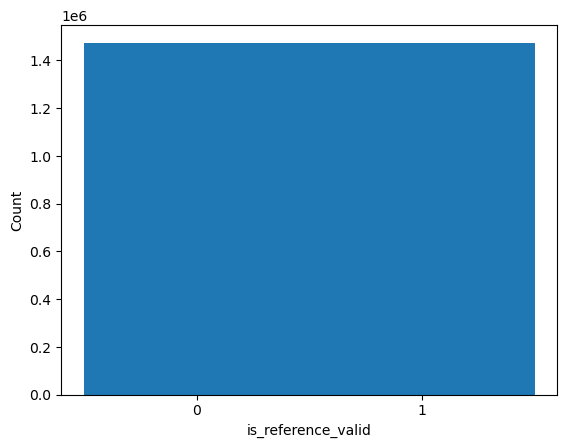

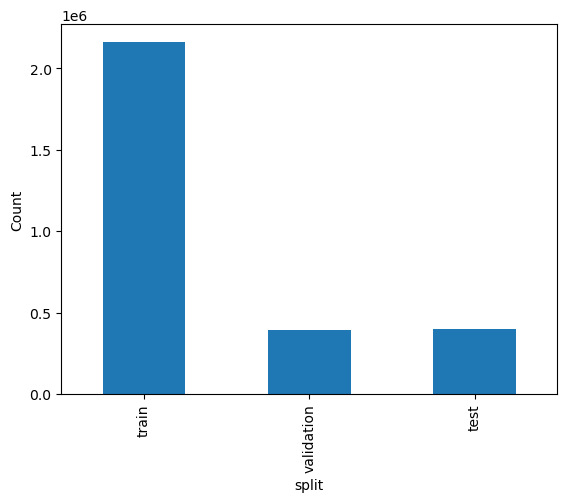

In [8]:
plt.hist(df["is_reference_valid"], bins=[-0.5, 0.5, 1.5])
plt.xticks([0, 1])
plt.xlabel("is_reference_valid")
plt.ylabel("Count")
plt.show()

# `split` is categorical, so a bar chart is clearer than a numeric histogram.
split_counts = df["split"].astype(str).str.lower().value_counts()
split_counts = split_counts.reindex(["train", "validation", "val", "test"]).dropna()
split_counts.plot(kind="bar")
plt.xlabel("split")
plt.ylabel("Count")
plt.show()

In [9]:
X = df.drop(columns=["is_reference_valid", "article_id", "ref_id", "vector_text_article", "vector_text_ref"], errors="ignore").copy()
y = df["is_reference_valid"].copy()

split_series = X["split"].astype(str).str.lower()
max_rows = len(X)  # Default to using all rows if the dataset is small
random_state = 42

train_idx = X.index[split_series == "train"]
test_idx = X.index[split_series == "test"]
val_idx = X.index[split_series.isin(["validation", "val"])]

# Random sampling avoids taking a contiguous block that may contain a single class.
train_idx = train_idx.to_series().sample(n=min(max_rows, len(train_idx)), random_state=random_state).index
test_idx = test_idx.to_series().sample(n=min(max_rows, len(test_idx)), random_state=random_state).index
val_idx = val_idx.to_series().sample(n=min(max_rows, len(val_idx)), random_state=random_state).index

X_train = X.loc[train_idx].drop(columns=["split"], errors="ignore")
y_train = y.loc[train_idx]
X_test = X.loc[test_idx].drop(columns=["split"], errors="ignore")
y_test = y.loc[test_idx]
X_val = X.loc[val_idx].drop(columns=["split"], errors="ignore")
y_val = y.loc[val_idx]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

print("Feature rows:", len(X))
print("Global label distribution:")
print(y.value_counts(normalize=True))
print("\nSplit sizes:", {"train": len(X_train), "test": len(X_test), "val": len(X_val)})
print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest label distribution:")
print(y_test.value_counts(normalize=True))
print("\nVal label distribution:")
print(y_val.value_counts(normalize=True))

del df, X, y, split_series, X_train, X_test, X_val

Feature rows: 2950135
Global label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64

Split sizes: {'train': 2162513, 'test': 396380, 'val': 391242}

Train label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64

Test label distribution:
is_reference_valid
1    0.500003
0    0.499997
Name: proportion, dtype: float64

Val label distribution:
is_reference_valid
0    0.5
1    0.5
Name: proportion, dtype: float64


In [10]:
y_train.value_counts()

is_reference_valid
1    1081260
0    1081253
Name: count, dtype: int64

In [11]:
from xgboost import XGBClassifier

# modello GPU
model = XGBClassifier(
    tree_method="hist",   # obbligatorio
    device="cuda"        # usa GPU
)

model.fit(X_train_scaled, y_train)

/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [22:09:10] WARNING: /home/task_177203090464722/croot/xgboost-split_1772031726713/work/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabete

In [12]:
from sklearn.model_selection import RandomizedSearchCV
import gc

# Valid hyperparameters for XGBClassifier
param_dist = {
    "n_estimators": [100, 200, 500],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [1, 5, 10],
    "scale_pos_weight": [1, 2, 5],
}

# On Windows, process-based CV workers can crash with large arrays/GPU contexts.
# Keep CV itself single-process to avoid TerminatedWorkerError.
search_n_jobs = 1

random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=20,
    cv=2,
    scoring="f1",
    random_state=42,
    n_jobs=search_n_jobs,
    pre_dispatch=search_n_jobs,
    error_score="raise",
    verbose=2,
)

# Run randomized search on the validation split (kept small by earlier sampling)
random_search.fit(X_val_scaled, y_val)

Fitting 2 folds for each of 20 candidates, totalling 40 fits


/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [22:09:37] WARNING: /home/task_177203090464722/croot/xgboost-split_1772031726713/work/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=10, n_estimators=100, reg_lambda=5, scale_pos_weight=5, subsample=1.0; total time=  19.3s


/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [22:09:57] WARNING: /home/task_177203090464722/croot/xgboost-split_1772031726713/work/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


KeyboardInterrupt: 

In [ ]:
import sys
import os
from pathlib import Path

# 1. Setup Path
root_path = Path(os.getcwd()).resolve().parents[2]
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

# 2. Forza il ricaricamento se hai modificato l'__init__
if 'utils' in sys.modules:
    del sys.modules['utils']

from utils.textual_utils.registry.model_saver import LocalModelRegistry

# 3. Configurazione salvataggio su /tmp
tmp_path = root_path / "tmp"
registry = LocalModelRegistry(registry_base_path=str(tmp_path))

# 4. Nome dinamico basato sui parametri del Random Forest
best_params = random_search.best_params_
n_trees = best_params.get('n_estimators', 100)
max_d = best_params.get('max_depth', 'None')
model_name_to_save = f"rf_n{n_trees}_d{max_d}"

dataset_info = {"df_name": "graph_features", "split_name": "predefined_train_validation_test"}

# 5. Salvataggio
run_dir = registry.save_experiment(
    model_name=model_name_to_save,
    model=model,
    params=best_params,
    metrics={
        "scoring": "f1_weighted",
        "max_tuning_samples": int(max_tuning_samples),
        "train_subset_size": int(len(train_tuning_idx)),
        "val_subset_size": int(len(val_tuning_idx)),
    },
    dataset_info=dataset_info
)

print(f"✅ Modello salvato in: {run_dir}")

NameError: name 'random_search' is not defined

              precision    recall  f1-score   support

           0     0.7614    0.8246    0.7917    198189
           1     0.8087    0.7416    0.7737    198191

    accuracy                         0.7831    396380
   macro avg     0.7851    0.7831    0.7827    396380
weighted avg     0.7851    0.7831    0.7827    396380



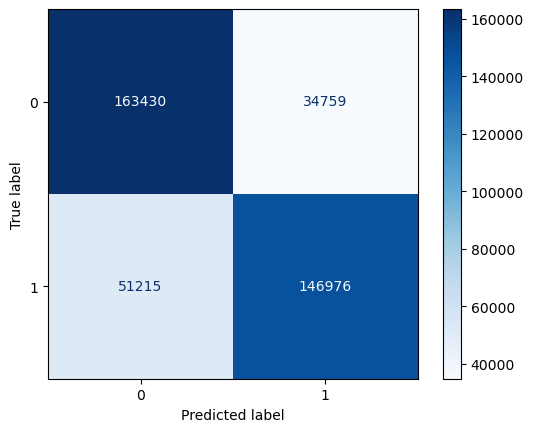

In [ ]:
best_model = random_search.best_estimator_
print("Best hyperparameters:", best_params)

y_pred = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap="Blues")

# Model interpretation

In [ ]:
explainer = shap.TreeExplainer(best_model)
shap_val = explainer.shap_values(X_val)

# summary plot
shap.summary_plot(shap_val, X_val)

# bar plot
shap.summary_plot(shap_val, X_val, plot_type="bar")